In [2]:


!pip install numpy pandas matplotlib opencv-python pillow torch torchvision pycocotools
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from pycocotools.coco import COCO
import requests
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
if not os.path.exists("/content/annotations_trainval2017.zip"):
    os.system("wget -c http://images.cocodataset.org/annotations/annotations_trainval2017.zip")

if not os.path.exists("/content/annotations/instances_train2017.json"):
    os.system("unzip -q -o /content/annotations_trainval2017.zip -d /content/")

annotation_file = "/content/annotations/instances_train2017.json"
image_folder = "/content/"

coco = COCO(annotation_file)

print("COCO loaded successfully")

loading annotations into memory...
Done (t=27.02s)
creating index...
index created!
COCO loaded successfully


In [5]:
image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256,256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor()
])

In [6]:
class CocoSegmentationDataset(Dataset):

    def __init__(self, coco, image_folder, category_name='person',
                 image_transform=None, mask_transform=None):

        self.coco = coco
        self.image_folder = image_folder
        self.category_name = category_name
        self.image_transform = image_transform
        self.mask_transform = mask_transform

        self.cat_ids = coco.getCatIds(catNms=[category_name])
        self.img_ids = coco.getImgIds(catIds=self.cat_ids)

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, index):

        img_id = self.img_ids[index]
        img_info = self.coco.loadImgs(img_id)[0]

        img_path = os.path.join(self.image_folder, img_info['file_name'])

        if not os.path.exists(img_path):

            url = f"http://images.cocodataset.org/train2017/{img_info['file_name']}"
            response = requests.get(url)

            with open(img_path, "wb") as f:
                f.write(response.content)

        image = Image.open(img_path).convert("RGB")
        image = np.array(image)

        ann_ids = self.coco.getAnnIds(
            imgIds=img_info['id'],
            catIds=self.cat_ids,
            iscrowd=None
        )

        anns = self.coco.loadAnns(ann_ids)

        mask = np.zeros((img_info['height'], img_info['width']))

        for ann in anns:
            mask += self.coco.annToMask(ann)

        mask = np.clip(mask,0,1).astype(np.uint8)

        if self.image_transform:
            image = self.image_transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)

        return image, mask

In [19]:
dataset = CocoSegmentationDataset(
    coco,
    image_folder,
    category_name='motorcycle',
    image_transform=image_transform,
    mask_transform=mask_transform
)

In [8]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset,[train_size,val_size])

print("Train:",len(train_dataset))
print("Validation:",len(val_dataset))

Train: 51292
Validation: 12823


In [9]:
train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=8,shuffle=False)

print("Train batches:",len(train_loader))
print("Val batches:",len(val_loader))

Train batches: 6412
Val batches: 1603


In [10]:
class DoubleConv(nn.Module):

    def __init__(self,in_channels,out_channels):

        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels,out_channels,3,padding=1),
            nn.ReLU()
        )

    def forward(self,x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.down1 = DoubleConv(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128,256)
        self.pool3 = nn.MaxPool2d(2)

        self.middle = DoubleConv(256,512)

        self.up1 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.conv1 = DoubleConv(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv2 = DoubleConv(256,128)

        self.up3 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv3 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        mid = self.middle(p3)

        up1 = self.up1(mid)
        m1 = torch.cat([up1,d3],dim=1)
        c1 = self.conv1(m1)

        up2 = self.up2(c1)
        m2 = torch.cat([up2,d2],dim=1)
        c2 = self.conv2(m2)

        up3 = self.up3(c2)
        m3 = torch.cat([up3,d1],dim=1)
        c3 = self.conv3(m3)

        out = self.final(c3)

        return torch.sigmoid(out)

In [14]:
import torchvision

model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)

model = model.to(device)
model.eval()

print("Pretrained model loaded")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:03<00:00, 55.0MB/s]


Pretrained model loaded


In [22]:
import random
idx = random.randint(0, len(dataset)-1)
image, mask = dataset[idx]

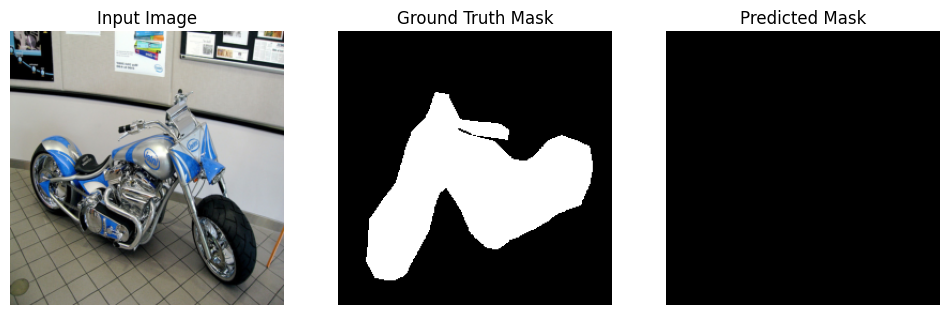

In [23]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image.permute(1,2,0))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred[0], cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

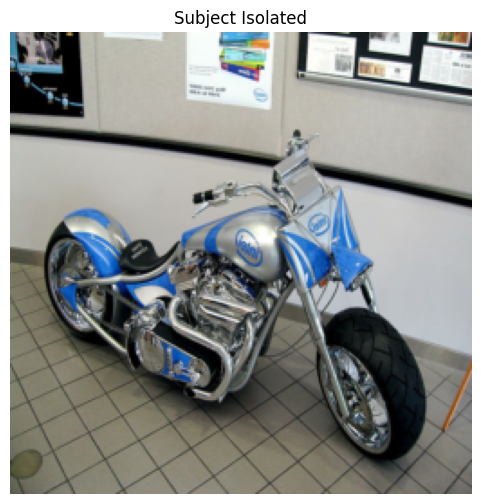

In [24]:
image_np = image.permute(1,2,0).numpy()

result = image_np.copy()

result[pred[0] == 0] = 0

plt.figure(figsize=(6,6))

plt.imshow(result)

plt.title("Subject Isolated")

plt.axis("off")

plt.show()

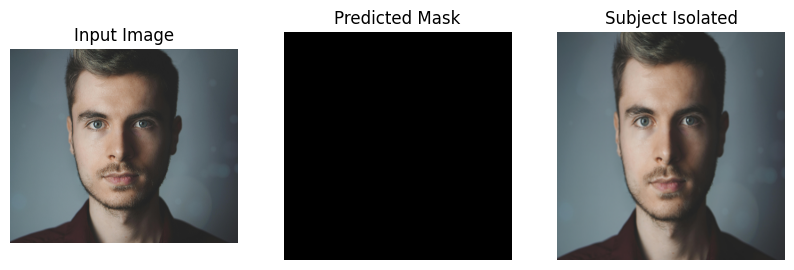

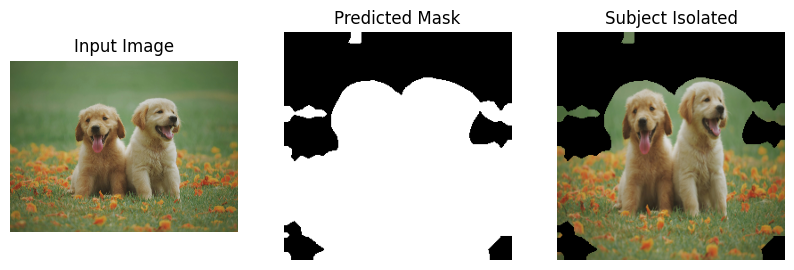

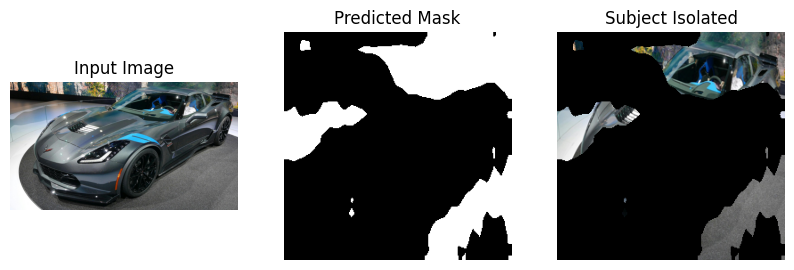

In [28]:
import requests
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load pretrained segmentation model
model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)
model.to(device)
model.eval()

# test images
image_urls = [
"https://images.pexels.com/photos/614810/pexels-photo-614810.jpeg",
"https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg",
"https://images.pexels.com/photos/358070/pexels-photo-358070.jpeg"
]

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

for url in image_urls:

    image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

    image_tensor = transform(image)

    with torch.no_grad():

        output = model(image_tensor.unsqueeze(0).to(device))

        pred = output['out']          # FIX HERE

    pred = pred.squeeze().cpu().numpy()

    pred = (pred[15] > 0.5).astype(np.uint8)   # class 15 = person

    image_np = np.array(image.resize((256,256)))

    result = image_np.copy()
    result[pred == 0] = 0

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(pred,cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(result)
    plt.title("Subject Isolated")
    plt.axis("off")

    plt.show()

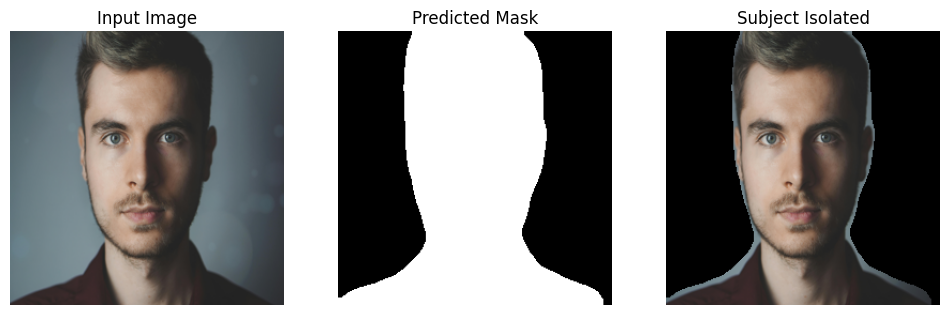

In [29]:
import torch
import torchvision
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load pretrained segmentation model
model = torchvision.models.segmentation.deeplabv3_resnet50(pretrained=True)
model.to(device)
model.eval()

# test image URL (person image)
image_url = "https://images.pexels.com/photos/614810/pexels-photo-614810.jpeg"

# download image
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# transform
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

image_tensor = transform(image)

# prediction
with torch.no_grad():

    output = model(image_tensor.unsqueeze(0).to(device))

    output = output['out'][0]   # shape [21,H,W]

# predicted class per pixel
pred = torch.argmax(output, dim=0).cpu().numpy()

# person class = 15
mask = (pred == 15).astype(np.uint8)

# resize original image
image_np = np.array(image.resize((256,256)))

# subject isolation
result = image_np.copy()
result[mask == 0] = 0

# visualization
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_np)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(result)
plt.title("Subject Isolated")
plt.axis("off")

plt.show()